# Fourier Transform for EEG: From Synthetic Signals to Real Data

**Audience:** students who are starting signal processing for EEG.

**Prerequisites:** basic Python, arrays, and simple plotting.

**By the end of this notebook, you will be able to:**
1. Build a complex-looking signal from simple sine/cosine components.
2. Use FFT to identify frequency peaks and compare with individual components.
3. Show how random noise changes the spectrum.
4. Load real EEG and inspect its frequency content.
5. Understand non-stationarity and why FFT alone is limited.
6. Reconstruct a signal with inverse Fourier transform and quantify similarity.

## Lesson Plan

1. **Warm-up: from simple waves to complex signal**
   - Generate several sine/cosine waves.
   - Sum them into one signal.
   - Show that FFT of the sum has peaks at component frequencies.
   - Overlay individual spectra with the total spectrum.

2. **Noise and spectral contamination**
   - Add random noise with increasing intensity.
   - Compare time-domain distortion and frequency-domain noise floor.

3. **Real EEG example**
   - Load BrainVision EEG data (`PD1001.vhdr`).
   - Plot one EEG channel in time.
   - Estimate and interpret spectrum/PSD and classical EEG bands.

4. **Non-stationary signals**
   - Build a signal whose frequency content changes over time.
   - Compare global FFT vs time-frequency spectrogram (STFT).

5. **Inverse Fourier transform and similarity**
   - Reconstruct signal from full spectrum (`iFFT`).
   - Compare with limited/magnitude-only reconstructions.
   - Quantify similarity using RMSE and correlation.

In [1]:
# ! pip install mne  <--- uncomment this

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# For EEG loading (BrainVision files)
import mne

In [3]:
# Reproducibility: fix random seed
RNG = np.random.default_rng(42)

# Plot style for readability in class
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

## Helper Functions

These helpers keep later cells short and focused on concepts.

In [4]:
def compute_fft_amplitude(x: np.ndarray, fs: float):
    # Return one-sided FFT frequencies and amplitudes.
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    amps = np.abs(np.fft.rfft(x)) * 2 / n
    return freqs, amps



### EEG as a Time Series

EEG is a **time series** — a sequence of values measured at **equal time intervals**.

### Why Look at the Frequency Domain?

When cognitive processing is reflected in changes in the **oscillatory components** of the EEG, this activity can be studied in the **frequency domain**.

# LETS GENERATE "EEG"

### 1) Sum of Sine and Cosine Components

We will create five simple oscillations, sum them, and inspect the result.

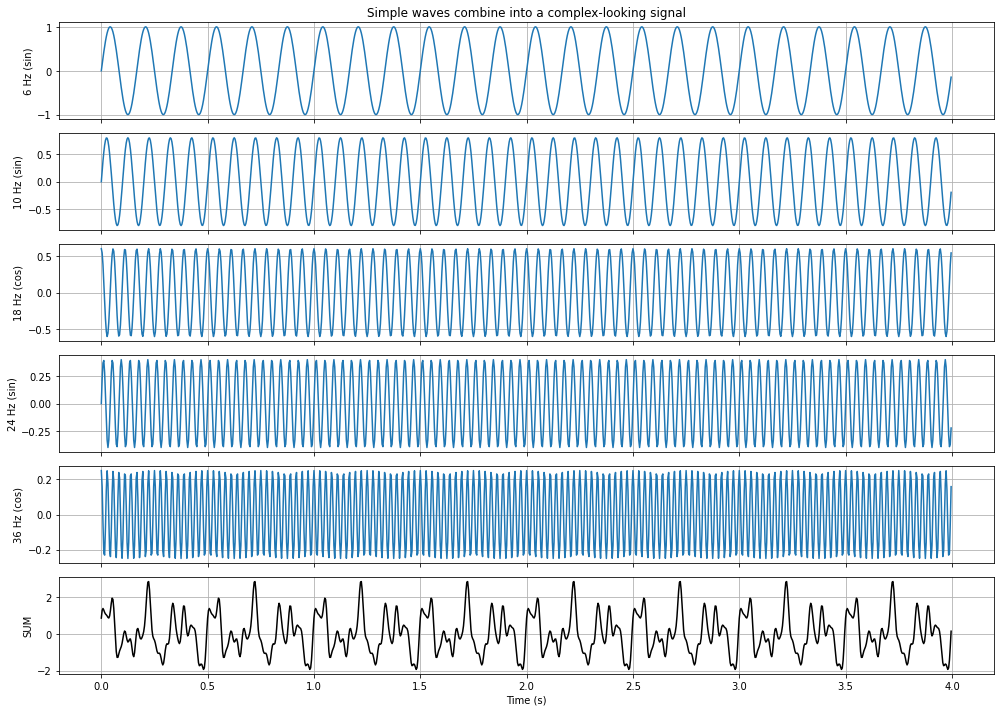

In [5]:
fs = 256  # Hz
duration = 4  # seconds
t = np.arange(0, duration, 1 / fs)


components = {
    '6 Hz (sin)': 1.0 * np.sin(2 * np.pi * 6 * t),
    '10 Hz (sin)': 0.8 * np.sin(2 * np.pi * 10 * t),
    '18 Hz (cos)': 0.6 * np.cos(2 * np.pi * 18 * t),
    '24 Hz (sin)': 0.4 * np.sin(2 * np.pi * 24 * t),
    '36 Hz (cos)': 0.25 * np.cos(2 * np.pi * 36 * t),
}

x_sum = np.sum(list(components.values()), axis=0)

# Plot individual components and their sum in time domain.
fig, axes = plt.subplots(len(components) + 1, 1, figsize=(14, 10), sharex=True)
for ax, (name, sig) in zip(axes[:-1], components.items()):
    ax.plot(t, sig)
    ax.set_ylabel(name)

    
 
axes[-1].plot(t, x_sum, color='black', linewidth=1.5)
axes[-1].set_ylabel('SUM')
axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Simple waves combine into a complex-looking signal')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Exercise </b><p>
Below, you will find code for generating a simulated “EEG” signal.  
Change the sampling frequency parameter `fs` by setting it to both **very low** and **very high** values, and observe how this affects the recorded signal.

Discuss:
- how the visual appearance of the signal changes,
- how accurately the signal is represented at different sampling rates,
- and why sampling frequency is important for EEG analysis.<p>


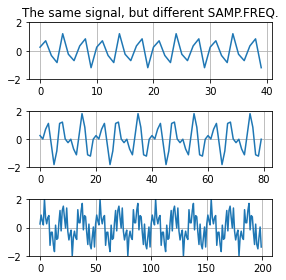

In [7]:
###########
fs1 = 20  # <-------CHANGE THIS
duration = 2  # seconds
t = np.arange(0, duration, 1 / fs1)
components = {
    '6 Hz (sin)': 1.0 * np.sin(2 * np.pi * 6 * t),
    '30 Hz (sin)': 0.8 * np.sin(2 * np.pi * 30 * t),
    '50 Hz (cos)': 0.25 * np.cos(2 * np.pi * 50 * t),
}
x_sum1 = np.sum(list(components.values()), axis=0)

###########
fs2 = 40  # <-------CHANGE THIS
t = np.arange(0, duration, 1 / fs2)
components = {
    '6 Hz (sin)': 1.0 * np.sin(2 * np.pi * 6 * t),
    '30 Hz (sin)': 0.8 * np.sin(2 * np.pi * 30 * t),
    '50 Hz (cos)': 0.25 * np.cos(2 * np.pi * 50 * t),
}
x_sum2 = np.sum(list(components.values()), axis=0)


###########
fs3 = 100  # <-------CHANGE THIS
t = np.arange(0, duration, 1 / fs3)
components = {
    '6 Hz (sin)': 1.0 * np.sin(2 * np.pi * 6 * t),
    '30 Hz (sin)': 0.8 * np.sin(2 * np.pi * 30 * t),
    '50 Hz (cos)': 0.25 * np.cos(2 * np.pi * 50 * t),
}
x_sum3 = np.sum(list(components.values()), axis=0)


# Plot individual components and their sum in time domain.
fig, axes = plt.subplots(3,1, figsize=(4, 4))
for ax, sig in zip(axes, [x_sum1, x_sum2, x_sum3]):
    ax.plot(sig)
    ax.set_ylim(-2,2)


axes[0].set_title('The same signal, but different SAMP.FREQ.')
plt.tight_layout()
plt.show()

#### Let's perform a Fourier transform.

In [8]:
fs = 256  # Hz
duration = 4  # seconds
t = np.arange(0, duration, 1 / fs)

components = {
    '6 Hz (sin)': 1.0 * np.sin(2 * np.pi * 6 * t),
    '10 Hz (sin)': 0.8 * np.sin(2 * np.pi * 10 * t),
    '18 Hz (cos)': 0.6 * np.cos(2 * np.pi * 18 * t),
    '24 Hz (sin)': 0.4 * np.sin(2 * np.pi * 24 * t),
    '36 Hz (cos)': 0.25 * np.cos(2 * np.pi * 36 * t),
}

x_sum = np.sum(list(components.values()), axis=0)

Text(0, 0.5, 'Amplitude')

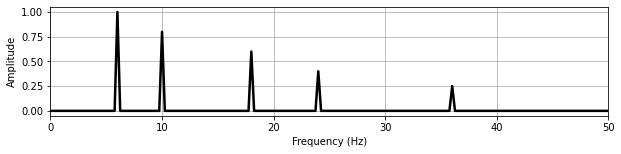

In [9]:
# Compare FFT of each component with FFT of the summed signal.
freq_sum, amp_sum = compute_fft_amplitude(x_sum, fs)

plt.figure(figsize=(10, 2))
plt.plot(freq_sum, amp_sum, color='black', linewidth=2.5, label='FFT of summed signal')

plt.xlim(0, 50)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')


### Unfortunately, the EEG is not simply the sum of harmonic functions.

#### 2) How Random Noise Affects Spectrum

Noise increases broadband energy and can hide true oscillatory peaks.

In [10]:
# We generate random signal
randon_noise = np.random.randn(len(x_sum))

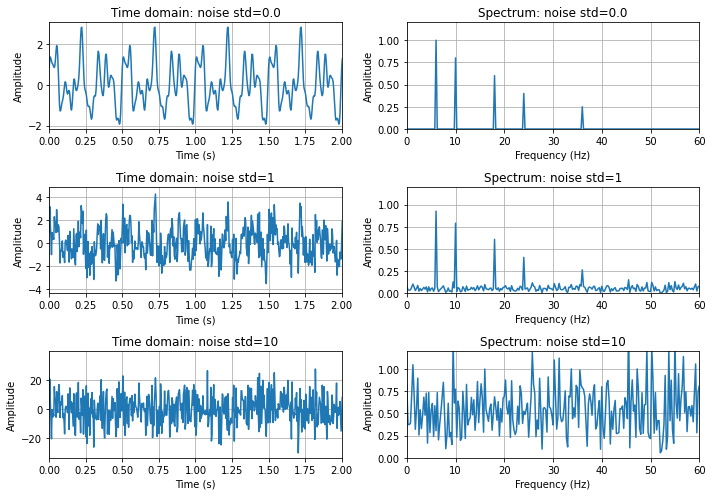

In [12]:
noise_levels = [0.0, 1, 10] #<--- Here we vary the noise amplitude (noise level).

noisy_signals = {
    f'noise std={nl}': x_sum + randon_noise*nl #<--- here we add noise to our signal
    for nl in noise_levels
}

fig, axes = plt.subplots(3, 2, figsize=(10, 7))
for row, (label, x_noisy) in enumerate(noisy_signals.items()):
    # Time-domain view
    axes[row, 0].plot(t, x_noisy)
    axes[row, 0].set_xlim(0, 2)
    axes[row, 0].set_title(f'Time domain: {label}')
    axes[row, 0].set_xlabel('Time (s)')
    axes[row, 0].set_ylabel('Amplitude')

    # Frequency-domain view
    f, a = compute_fft_amplitude(x_noisy, fs)
    axes[row, 1].plot(f, a)
    axes[row, 1].set_xlim(0, 60)
    axes[row, 1].set_ylim(0, 1.2)
    
    axes[row, 1].set_title(f'Spectrum: {label}')
    axes[row, 1].set_xlabel('Frequency (Hz)')
    axes[row, 1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Exercise </b><p>
Play around with the noise level values in the code above and discuss how this affects the signal and spectrum.

## 3) Open Real EEG and Analyze Spectrum

We load your local BrainVision file and inspect one channel.

In [13]:
eeg_file = 'eeg_raw/PD1001.vhdr'

raw = mne.io.read_raw_brainvision(eeg_file, preload=True, verbose='ERROR')
raw.pick('eeg')
fs_eeg = raw.info['sfreq']

print(f'Loaded EEG with {len(raw.ch_names)} channels')
print(f'Sampling frequency: {fs_eeg:.1f} Hz')
print(f'Duration: {raw.times[-1]:.1f} s')
print('First 8 channels:', raw.ch_names)

Loaded EEG with 63 channels
Sampling frequency: 500.0 Hz
Duration: 281.7 s
First 8 channels: ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2', 'FCz']


Using matplotlib as 2D backend.


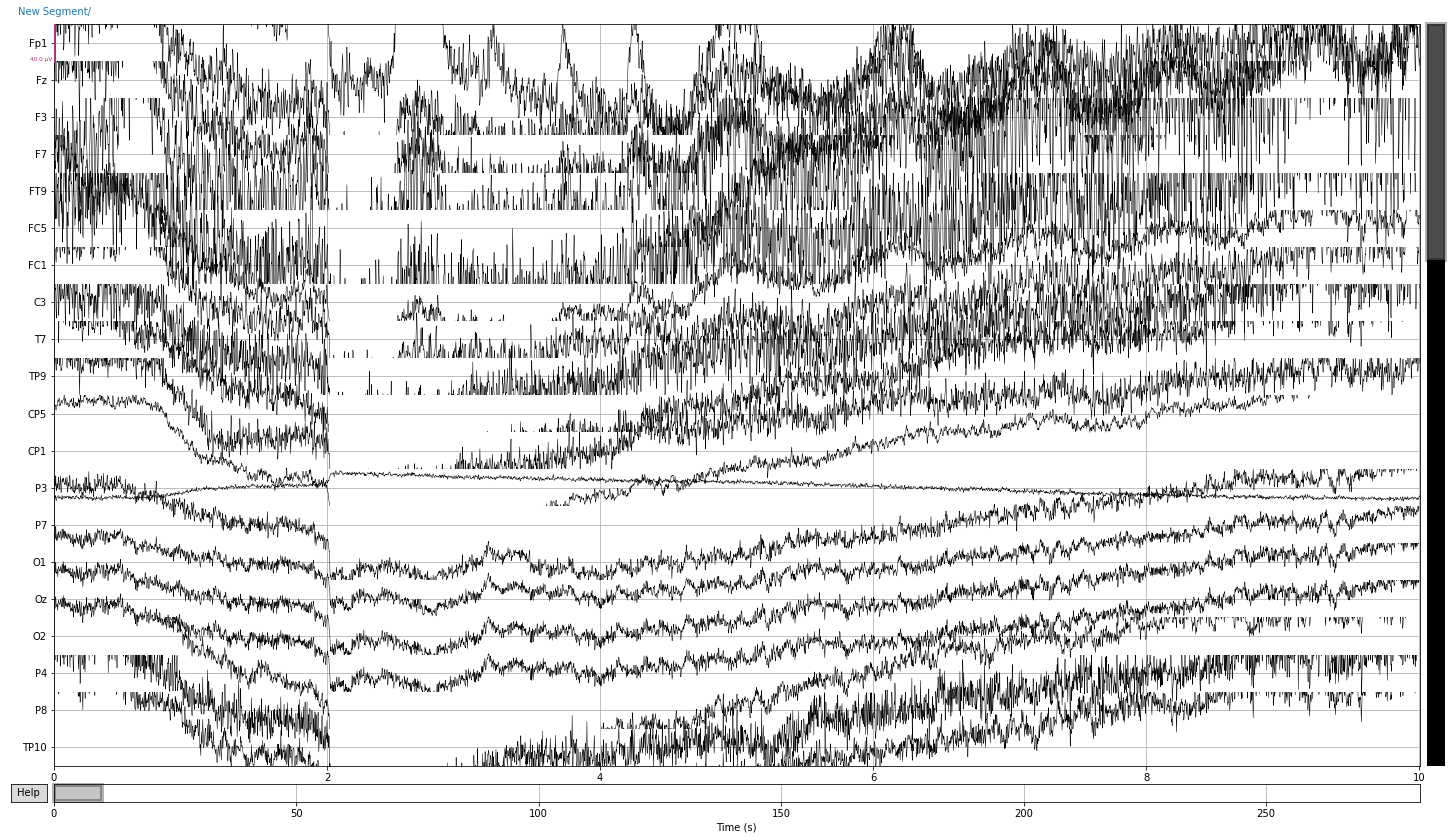

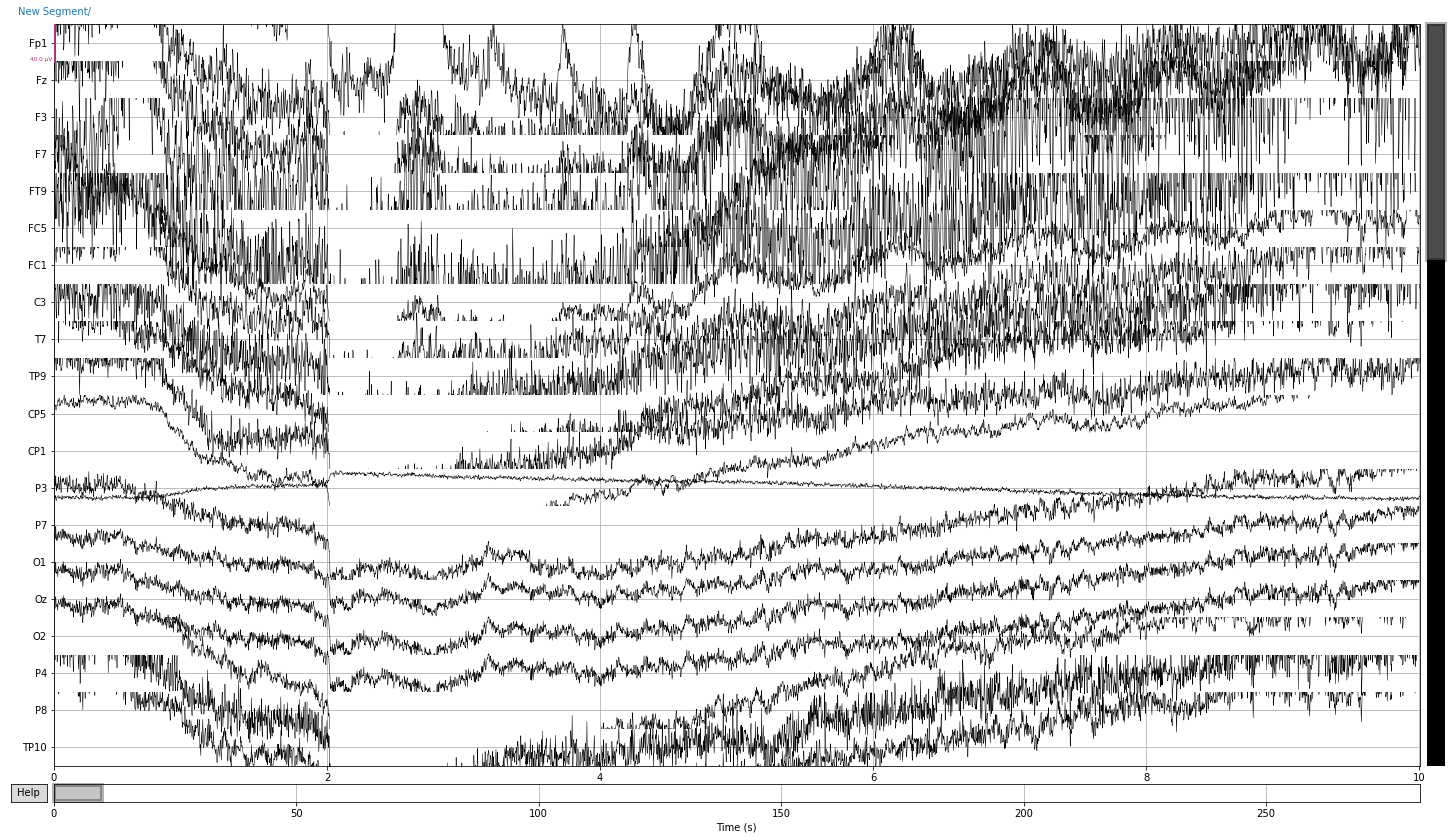

In [14]:
raw.plot()

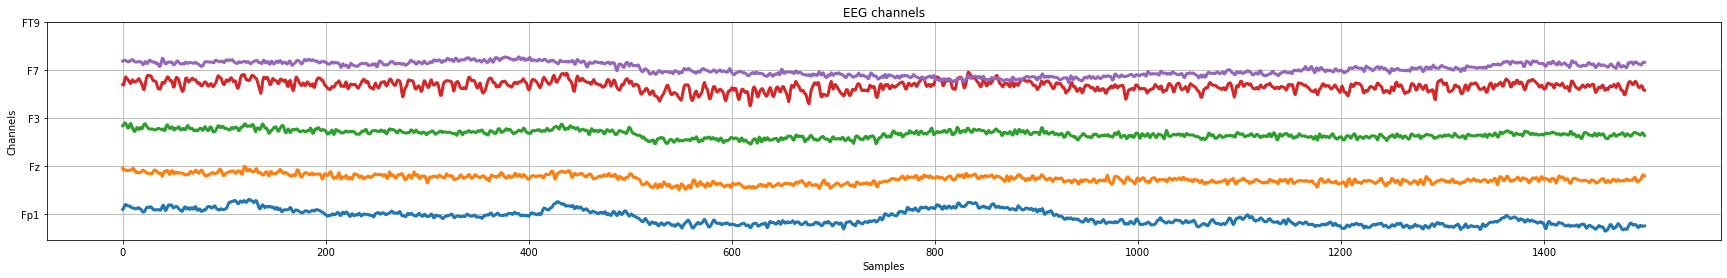

In [15]:
n_channels = 5
offset = 4 / 10000

plt.figure(figsize=(30, 4))

ytick_positions = []
ytick_labels = []

for i in range(n_channels):
    y = raw.get_data()[i, 500:2000] + i * offset
    plt.plot(y, linewidth=3)
    ytick_positions.append(i * offset)
    ytick_labels.append(raw.ch_names[i])

plt.yticks(ytick_positions, ytick_labels)
plt.xlabel("Samples")
plt.ylabel("Channels")
plt.title("EEG channels")
plt.show()

### compute spectrum for EEG

In [16]:
raw = raw.filter(l_freq=0.5, h_freq=100)
raw_filtred = raw.copy()

raw_filtred.filter(l_freq=1, h_freq=30)
eeg_data = raw_filtred.get_data()


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 3301 samples (6.602 sec)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passba

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


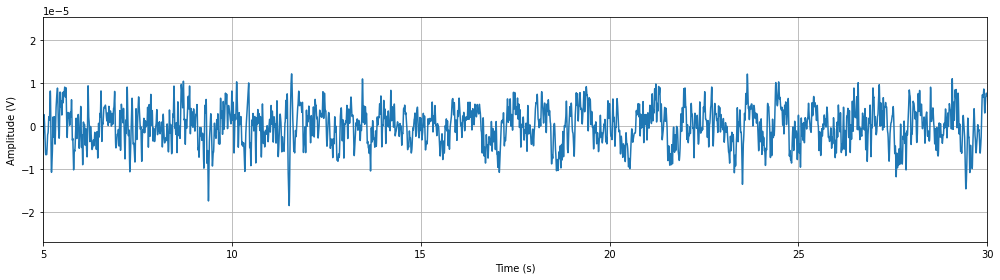

Effective window size : 4.000 (s)


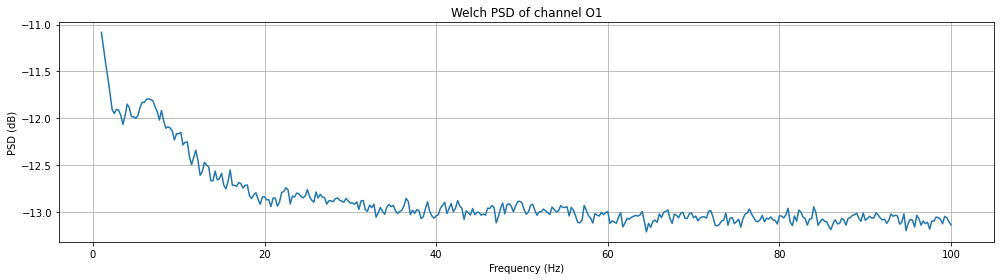

In [17]:
# Select one channel and a fixed window for demonstration.

ch_index = raw.ch_names.index('O1')
channel = raw.ch_names[ch_index]
# Plot EEG segment in time domain.
plt.figure(figsize=(14, 4))
plt.plot(raw.times, eeg_data[ch_index], color='tab:blue')
plt.xlim(5,30)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.tight_layout()
plt.show()

# Calculation of PSD 

spectrum = raw.compute_psd(
    method='welch',
    fmin=1,
    fmax=100,
    n_fft=2000)

freqs_psd = spectrum.freqs
plt.figure(figsize=(14, 4))
plt.plot(freqs_psd, np.log10(spectrum.get_data()[ch_index]))
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB)')
plt.title(f'Welch PSD of channel {channel}')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Exercise </b><p>
Plot the spectrum for channels C3 and F3, and compare it with the previously plotted occipital channel.

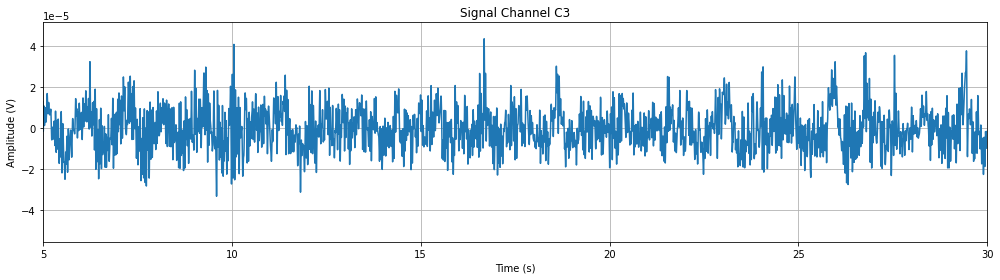

Effective window size : 4.000 (s)


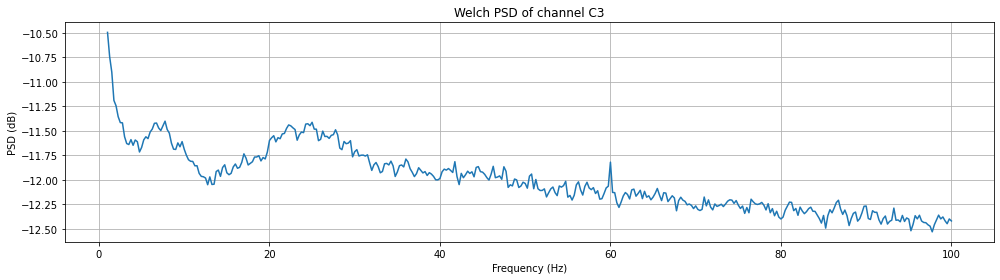

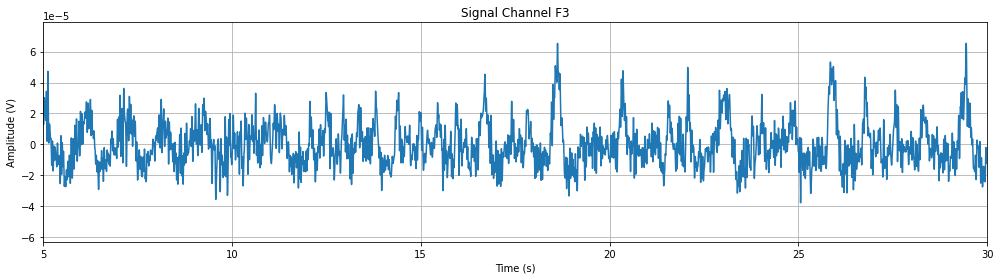

Effective window size : 4.000 (s)


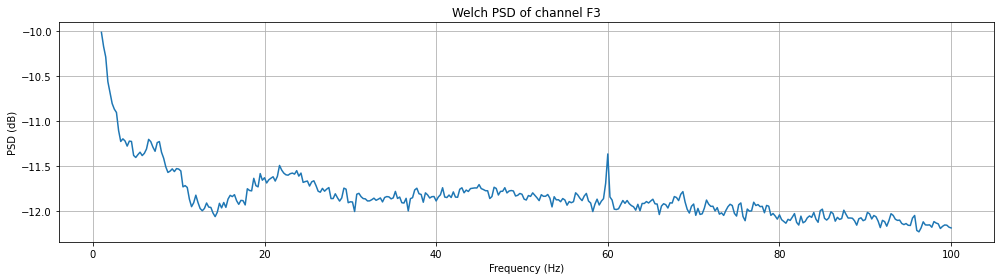

In [21]:
# The spectrum for channels C3 and F3,

for c in ['C3', 'F3']:
    ch_index = raw.ch_names.index(c)
    channel = raw.ch_names[ch_index]
    # Plot EEG segment in time domain.
    plt.figure(figsize=(14, 4))
    plt.title(f'Signal Channel {c}')
    plt.plot(raw.times, eeg_data[ch_index], color='tab:blue')
    plt.xlim(5,30)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (V)')
    plt.tight_layout()
    plt.show()

    # Calculation of PSD 

    spectrum = raw.compute_psd(
        method='welch',
        fmin=1,
        fmax=100,
        n_fft=2000)

    freqs_psd = spectrum.freqs
    plt.figure(figsize=(14, 4))
    plt.plot(freqs_psd, np.log10(spectrum.get_data()[ch_index]))
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (dB)')
    plt.title(f'Welch PSD of channel {channel}')
    plt.tight_layout()
    plt.show()

In [22]:
raw.ch_names

['Fp1',
 'Fz',
 'F3',
 'F7',
 'FT9',
 'FC5',
 'FC1',
 'C3',
 'T7',
 'TP9',
 'CP5',
 'CP1',
 'P3',
 'P7',
 'O1',
 'Oz',
 'O2',
 'P4',
 'P8',
 'TP10',
 'CP6',
 'CP2',
 'Cz',
 'C4',
 'T8',
 'FT10',
 'FC6',
 'FC2',
 'F4',
 'F8',
 'Fp2',
 'AF7',
 'AF3',
 'AFz',
 'F1',
 'F5',
 'FT7',
 'FC3',
 'C1',
 'C5',
 'TP7',
 'CP3',
 'P1',
 'P5',
 'PO7',
 'PO3',
 'POz',
 'PO4',
 'PO8',
 'P6',
 'P2',
 'CPz',
 'CP4',
 'TP8',
 'C6',
 'C2',
 'FC4',
 'FT8',
 'F6',
 'AF8',
 'AF4',
 'F2',
 'FCz']

Effective window size : 4.000 (s)


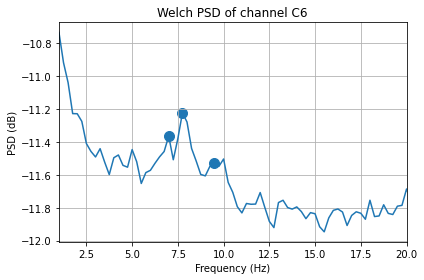

In [23]:
ch_index = raw.ch_names.index('C6')
channel = raw.ch_names[ch_index]
spectrum = raw.compute_psd(
    method='welch',
    fmin=1,
    fmax=40,
    n_fft=2000)
psd = np.log10(spectrum.get_data()[ch_index])
freqs_psd = spectrum.freqs
plt.figure(figsize=(6, 4))
plt.plot(freqs_psd, psd)

freqmask = np.where((freqs_psd<10)&(freqs_psd>5))[0]
peaks = signal.find_peaks(psd[freqmask])[0]+freqmask[0]
plt.scatter(freqs_psd[peaks], psd[peaks], s=100)

plt.xlim(1,20)

plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB)')
plt.title(f'Welch PSD of channel {channel}')
plt.tight_layout()
plt.show()

## 4) Non-Stationary Signal: Why Global FFT Is Not Enough

A global FFT gives *which* frequencies exist, but not *when* they are active.

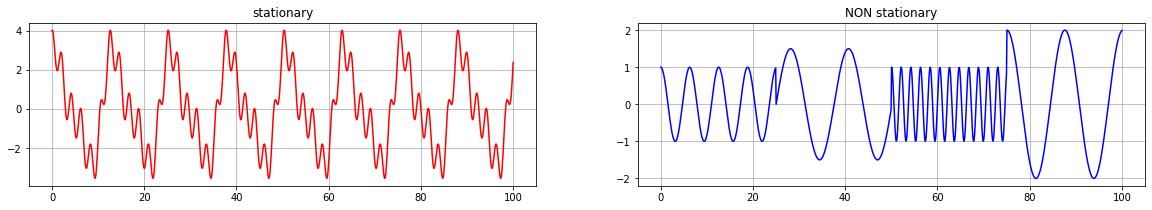

In [24]:
fs_ns = 1000
duration = 100
time = np.linspace(0,duration,fs_ns)

s2 = 1.5*np.sin(time/2)
s3 = np.cos(time*3)
s4 = 2*np.cos(time/2)
s5 = np.cos(time)
stationary = s2+s3+s4+s5


s2_1 = s2[:int(len(time)/4),]
s3_1 = s3[:int(len(time)/4),]
s4_1 = s4[:int(len(time)/4),]
s5_1 = s5[:int(len(time)/4),]
nonstationary = np.concatenate([s5_1,s2_1,s3_1,s4_1])


fig = plt.figure(figsize = (20,3))
ax5 = fig.add_subplot(1,2,1)
ax5.title.set_text('stationary')
ax5.plot(time, stationary, color = 'red')
ax5 = fig.add_subplot(1,2,2)
ax5.title.set_text('NON stationary')
ax5.plot(time, nonstationary, color = 'b')

In [25]:
# Global FFT comparison.
f_stat, a_stat = compute_fft_amplitude(stationary, fs_ns)
f_non, a_non = compute_fft_amplitude(nonstationary, fs_ns)

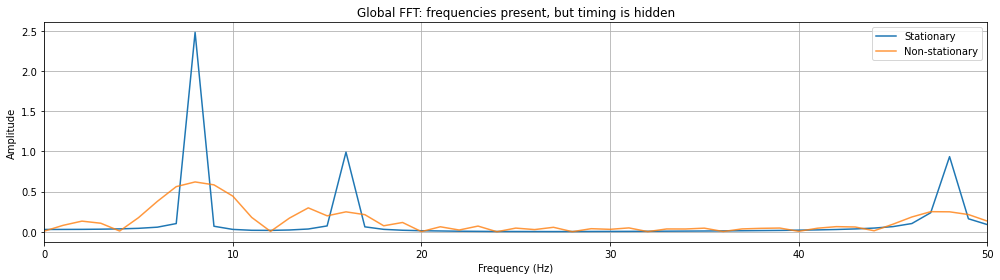

In [26]:
# Global FFT comparison.
f_stat, a_stat = compute_fft_amplitude(stationary, fs_ns)
f_non, a_non = compute_fft_amplitude(nonstationary, fs_ns)

plt.figure(figsize=(14, 4))
plt.plot(f_stat, a_stat, label='Stationary')
plt.plot(f_non, a_non, label='Non-stationary', alpha=0.8)
plt.xlim(0, 50)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Global FFT: frequencies present, but timing is hidden')
plt.legend()
plt.tight_layout()
plt.show()


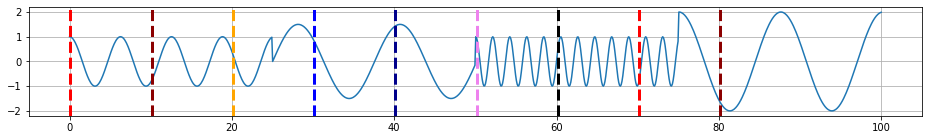

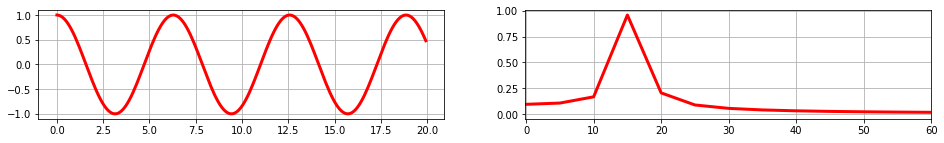

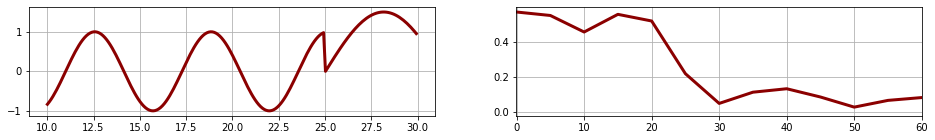

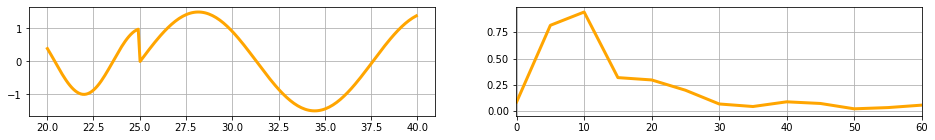

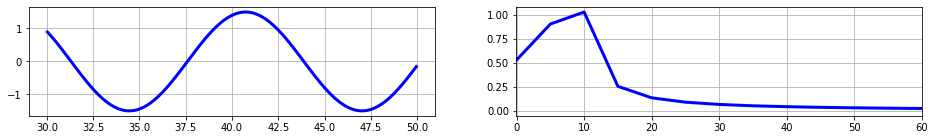

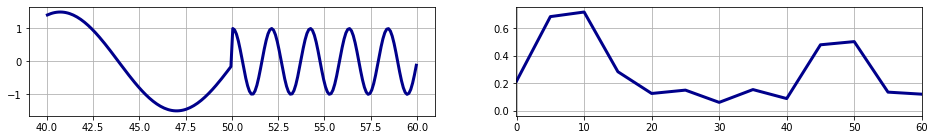

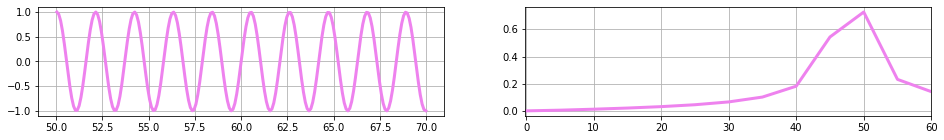

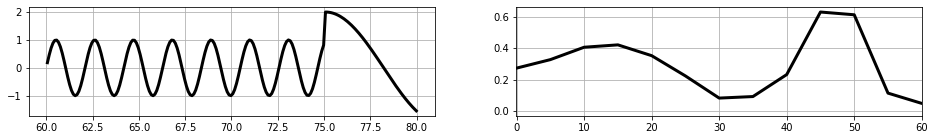

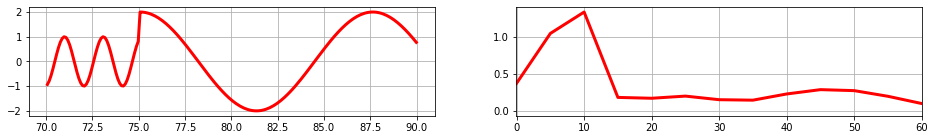

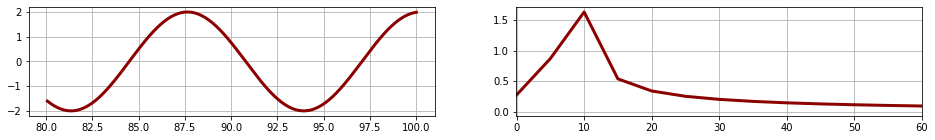

In [27]:
win = 200
f = plt.figure(figsize = (16,2))
ax = f.add_subplot(1,1,1)
ax.plot(time, nonstationary)

colors = ['red', 'darkred', 'orange','blue', 'darkblue', 'violet','black']*int(len(time)/win)

# random.shuffle(colors)

for ix, i in enumerate(range(0,len(time)-int(win/2), int(win/2))):
    time_int = time[i:i+win]
    ax.axvline(time_int[1], color = colors[ix], linestyle='--', linewidth =3)
    nonstationary_int = nonstationary[i:i+win]
    
    xf, nonstationary_int_win = compute_fft_amplitude(nonstationary_int, fs_ns)

    plt.figure(figsize = (16,2))
    plt.subplot(1,2,2)
    plt.plot(xf, nonstationary_int_win, linewidth = 3, color = colors[ix])
    plt.xlim(-0.1,60)
    
    plt.subplot(1,2,1)
    plt.plot(time_int, nonstationary_int, linewidth = 3, color = colors[ix])
plt.show() ;

/Users/nikolaj_syrov/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  """
/Users/nikolaj_syrov/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  # Remove the CWD from sys.path while we load stuff.


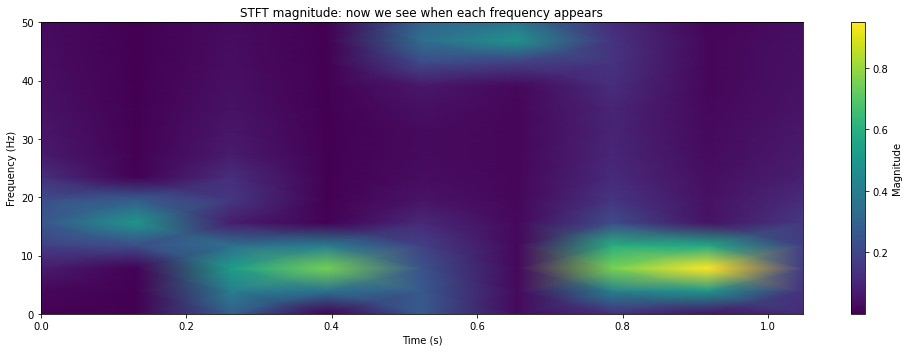

In [28]:

# Time-frequency representation (STFT) for non-stationary signal.
f_stft, t_stft, Zxx = signal.stft(nonstationary, fs=fs_ns, nperseg=256, noverlap=125)

plt.figure(figsize=(14, 5))
plt.pcolormesh(t_stft, f_stft, np.abs(Zxx), shading='gouraud')
plt.ylim(0, 50)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('STFT magnitude: now we see when each frequency appears')
plt.colorbar(label='Magnitude')
plt.tight_layout()
plt.show()

In [29]:
f_stft.shape

(129,)

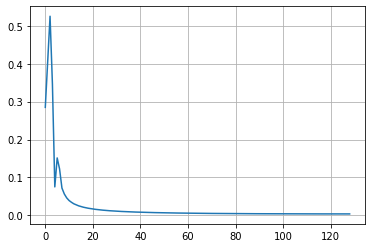

In [30]:
plt.plot(np.abs(Zxx)[:,2])

## 5) Inverse Fourier Transform and Signal Similarity

Reconstruct from spectrum and quantify how close reconstructions are.

In [31]:
def similarity_metrics(x_true: np.ndarray, x_pred: np.ndarray):
    # Basic similarity metrics for reconstruction quality.
    n = min(len(x_true), len(x_pred))
    x_t = x_true[:n]
    x_p = x_pred[:n]
    rmse = np.sqrt(np.mean((x_t - x_p) ** 2))
    corr = np.corrcoef(x_t, x_p)[0, 1]
    return {'RMSE': rmse, 'Correlation': corr}




In [32]:
x_target = x_sum.copy()
n = len(x_target)

# Full reconstruction (should be nearly perfect).
X = np.fft.rfft(x_target)
x_rec_full = np.fft.irfft(X, n=n)

# Low-pass reconstruction (remove high frequencies > 20 Hz).
freqs_r = np.fft.rfftfreq(n, d=1 / fs)
X_low = X.copy()
X_low[freqs_r > 20] = 0
x_rec_low = np.fft.irfft(X_low, n=n)

# Magnitude-only (zero phase) reconstruction to show phase importance.
X_mag_only = np.abs(X) + 0j
x_rec_mag_only = np.fft.irfft(X_mag_only, n=n)

metrics = pd.DataFrame([
    {'Method': 'Full iFFT', **similarity_metrics(x_target, x_rec_full)},
    {'Method': 'Low-pass iFFT', **similarity_metrics(x_target, x_rec_low)},
    {'Method': 'Magnitude-only iFFT', **similarity_metrics(x_target, x_rec_mag_only)},
])
metrics

,Method,RMSE,Correlation
0,Full iFFT,2.566166e-16,1.000000
1,Low-pass iFFT,3.335416e-01,0.948624
2,Magnitude-only iFFT,1.341641e+00,0.190101


In [33]:
fs = 500  # Hz
duration = 4  # seconds
t = np.arange(0, duration, 1 / fs)

components = {
    '6 Hz (sin)': 1.0 * np.sin(2 * np.pi * 6 * t),
    '10 Hz (sin)': 0.8 * np.sin(2 * np.pi * 10 * t),
    '18 Hz (cos)': 0.6 * np.cos(2 * np.pi * 18 * t),
    '24 Hz (sin)': 0.4 * np.sin(2 * np.pi * 24 * t),
    '36 Hz (cos)': 0.25 * np.cos(2 * np.pi * 36 * t),
}

x_sum = np.sum(list(components.values()), axis=0)

x_target = x_sum.copy()
n = len(x_target)

# Full reconstruction (should be nearly perfect).
X = np.fft.rfft(x_target)
x_rec_full = np.fft.irfft(X, n=n)


ch_index = raw.ch_names.index('F1')
x_eeg = eeg_data[ch_index].copy()
n2 = len(x_eeg)

Xeeg = np.fft.rfft(x_eeg)
x_eeg_rec_full = np.fft.irfft(Xeeg, n=n2)

# Low-pass reconstruction (remove high frequencies > 20 Hz).
freqs_r = np.fft.rfftfreq(n2, d=1 / raw.info['sfreq'])
Xeeg_low = Xeeg.copy()
Xeeg_low[freqs_r > 10] = 0
x_eeg_rec_low = np.fft.irfft(Xeeg_low, n=n2)


metrics = pd.DataFrame([
    {'Method': 'Full iFFT synthetic', **similarity_metrics(x_target, x_rec_full)},
    {'Method': 'Full iFFT eeg', **similarity_metrics(x_eeg, x_eeg_rec_full)},
    {'Method': 'Lowfreq iFFT eeg', **similarity_metrics(x_eeg, x_eeg_rec_low)},
    
])
metrics

,Method,RMSE,Correlation
0,Full iFFT synthetic,3.504945e-16,1.000000
1,Full iFFT eeg,8.333507e-21,1.000000
2,Lowfreq iFFT eeg,4.443747e-06,0.918592


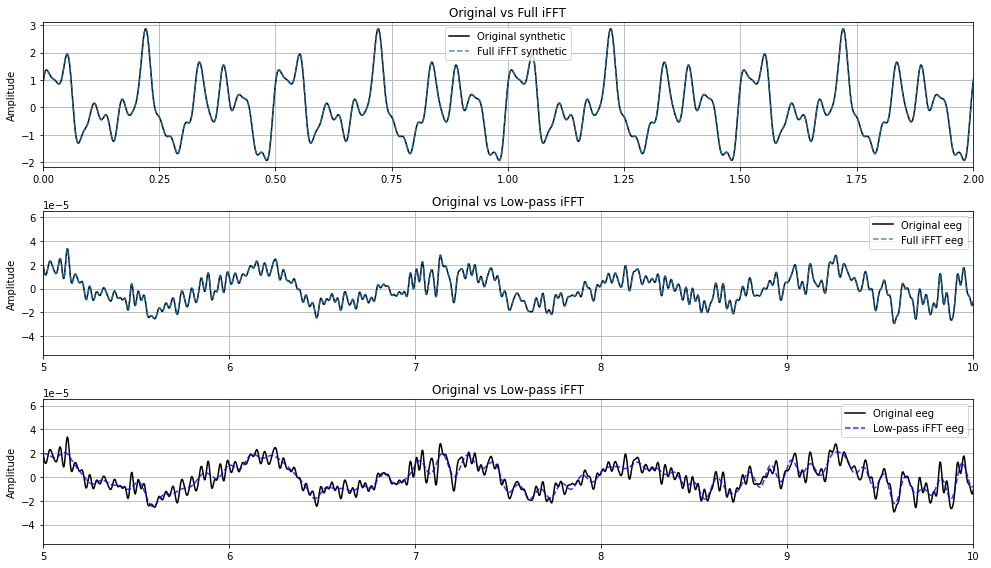

In [34]:
# Visual comparison in time domain.
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(t, x_target, color='black', label='Original synthetic')
axes[0].plot(t, x_rec_full, '--', label='Full iFFT synthetic', alpha=0.8)
axes[0].set_title('Original vs Full iFFT')
axes[0].legend()
axes[0].set_xlim(0, 2)
axes[0].set_ylabel('Amplitude')


axes[1].plot(raw.times, x_eeg, color='black', label='Original eeg')
axes[1].plot(raw.times, x_eeg_rec_full, '--', label='Full iFFT eeg', alpha=0.8)
axes[1].set_title('Original vs Low-pass iFFT')
axes[1].legend()
axes[1].set_xlim(5, 10)
axes[1].set_ylabel('Amplitude')


axes[2].plot(raw.times, x_eeg, color='black', label='Original eeg')
axes[2].plot(raw.times, x_eeg_rec_low, '--', label='Low-pass iFFT eeg', alpha=0.8, color='blue')
axes[2].set_title('Original vs Low-pass iFFT')
axes[2].legend()
axes[2].set_xlim(5, 10)
axes[2].set_ylabel('Amplitude')


plt.tight_layout()
plt.show()